In [20]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
from linearregression import LinearRegression
from sklearn import linear_model
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

In [21]:
df = pd.read_csv('Salary_dataset.csv')
df.head(10)

,Unnamed: 0,YearsExperience,Salary
0,0,1.2,39344.0
1,1,1.4,46206.0
2,2,1.6,37732.0
3,3,2.1,43526.0
4,4,2.3,39892.0
5,5,3.0,56643.0
6,6,3.1,60151.0
7,7,3.3,54446.0
8,8,3.3,64446.0
9,9,3.8,57190.0


In [22]:
df.describe()

,Unnamed: 0,YearsExperience,Salary
count,30.000000,30.000000,30.000000
mean,14.500000,5.413333,76004.000000
std,8.803408,2.837888,27414.429785
min,0.000000,1.200000,37732.000000
25%,7.250000,3.300000,56721.750000
50%,14.500000,4.800000,65238.000000
75%,21.750000,7.800000,100545.750000
max,29.000000,10.600000,122392.000000


In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Unnamed: 0       30 non-null     int64  
 1   YearsExperience  30 non-null     float64
 2   Salary           30 non-null     float64
dtypes: float64(2), int64(1)
memory usage: 852.0 bytes


In [24]:
df.corr()

,Unnamed: 0,YearsExperience,Salary
Unnamed: 0,1.000000,0.986460,0.960826
YearsExperience,0.986460,1.000000,0.978242
Salary,0.960826,0.978242,1.000000


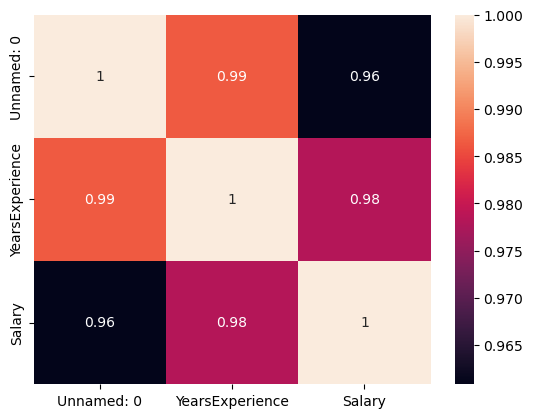

In [25]:
sns.heatmap(df.corr(), annot = True)
plt.show()

In [26]:
x = df[['YearsExperience']]
y = df['Salary']

In [27]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42)

In [28]:
from linearregression import StandardScaler 

x_scaler = StandardScaler()
x_train = x_scaler.fit_transform(x_train)
x_test = x_scaler.transform(x_test)

y_scaler = StandardScaler()
y_train = y_scaler.fit_transform(y_train)
y_test = y_scaler.transform(y_test)

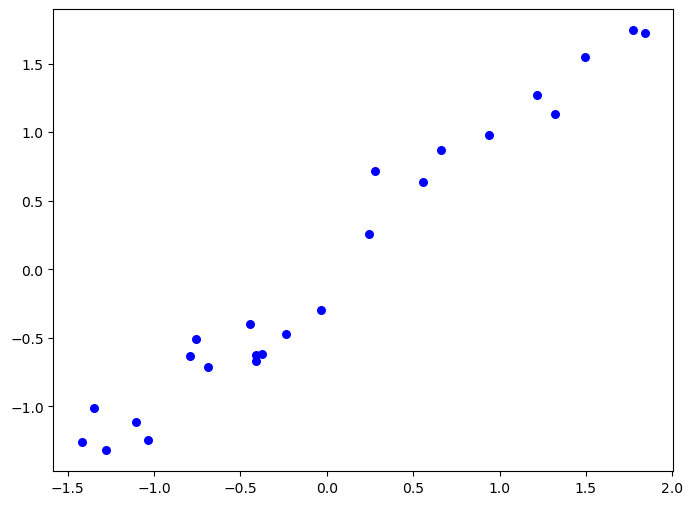

In [29]:
fig = plt.figure(figsize = (8,6))
plt.scatter(x_train, y_train, color = 'b', marker = 'o', s = 30)
plt.show()

In [30]:
df.isnull().sum()

Unnamed: 0         0
YearsExperience    0
Salary             0
dtype: int64

In [31]:
model_custom = LinearRegression(lr = 0.01, n_iters = 400)
model_sklearn = linear_model.LinearRegression()

In [32]:
x_train.shape

(24, 1)

In [33]:
y_train.shape

(24,)

In [34]:
model_custom.fit(x_train, y_train)
model_sklearn.fit(x_train, y_train)

Loss0.000000
Loss0.000000
Loss0.000000
Loss0.000000


LinearRegression()

In [35]:
x_input = x_scaler.transform([[8]])
y_predz_customed =  model_custom.predict(x_test)
y_actual_customed = y_scaler.inverse_transform(y_predz_customed.reshape(-1,1))
y_predz_sklearn = model_sklearn.predict(x_test)
y_actual_sklearn = y_scaler.inverse_transform(y_predz_sklearn.reshape(-1, 1))

print(f'Predicted Salary Custom: {y_actual_customed[0][0]:,.2f}')
print(f'Predicted Salary Sklearn: {y_actual_sklearn[0][0]:,.2f}')

Predicted Salary Custom: 115,044.78
Predicted Salary Sklearn: 115,791.21


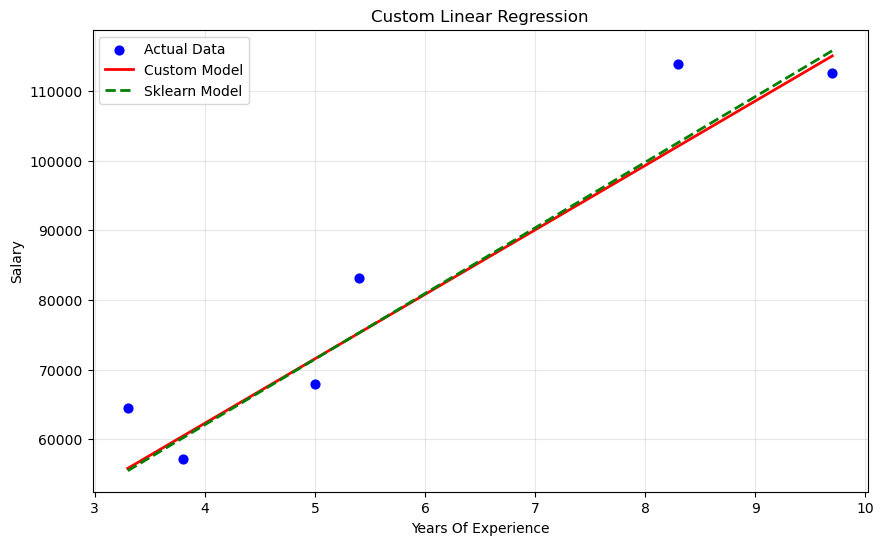

In [36]:
x_test_actual = x_scaler.inverse_transform(x_test).flatten()
y_test_actual = y_scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()


x_range = np.linspace(x_test.min(), x_test.max(), 100).reshape(-1, 1)
x_range_actual = x_scaler.inverse_transform(x_range).flatten()

plt.figure(figsize = (10, 6))

y_custom_line = y_scaler.inverse_transform(model_custom.predict(x_range).reshape(-1, 1)).flatten()
y_sklearn_line = y_scaler.inverse_transform(model_sklearn.predict(x_range).reshape(-1, 1)).flatten() 

plt.scatter(x_test_actual, y_test_actual, color = 'blue', label = 'Actual Data', s = 40, zorder = 3)
plt.plot(x_range_actual, y_custom_line, color = 'red', linewidth = 2, label = 'Custom Model')
plt.plot(x_range_actual, y_sklearn_line, color = 'green', linewidth = 2, linestyle = '--', label = 'Sklearn Model')

plt.xlabel('Years Of Experience')
plt.ylabel('Salary')
plt.title('Custom Linear Regression')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [37]:
custom = model_custom.score(x_test, y_test)
sklearnz = model_sklearn.score(x_test, y_test)
print(f'Score of custom model: {custom}')
print(f'Score of sklearn model: {sklearnz}')

Score of custom model: 0.901193066709229
Score of sklearn model: 0.9024461774180499


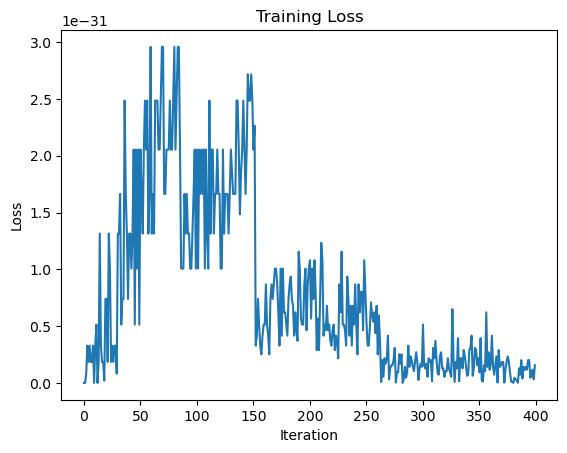

In [38]:
plt.plot(model_custom.loss_history)
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.show()